# SIFT

## Import libraries

In [14]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Load input images


In [15]:
box = cv.imread("Images/100tomani.jpg")
box_in = cv.imread("Images/eskenas.jpg")

# Convert images to grayscale for SIFT feature detection
box_gray = cv.cvtColor(box, cv.COLOR_BGR2GRAY)
box_in_gray = cv.cvtColor(box_in, cv.COLOR_BGR2GRAY)

# Create SIFT detector and extract keypoints + descriptors


In [16]:
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(box_gray, None)
kp2, des2 = sift.detectAndCompute(box_in_gray, None)

# Create Brute Force matcher
## Using KNN matching to compare descriptors


In [17]:
bf = cv.BFMatcher(cv.NORM_L1, crossCheck=False)
knn_match = bf.knnMatch(des1, des2, k=2)

# Apply Lowe's Ratio Test to filter weak matches
good = []
for m, n in knn_match:
    if m.distance < .75 * n.distance:
        good.append(m)

# Object Localization with Homography and RANSAC

In [18]:
# Continue only if enough good matches are found
if len(good) > 10:

    # Extract matching keypoint coordinates
    pts1 = np.float32(
        [kp1[m.queryIdx].pt for m in good]
    ).reshape(-1, 1, 2)

    pts2 = np.float32(
        [kp2[m.trainIdx].pt for m in good]
    ).reshape(-1, 1, 2)

    # Compute homography matrix using RANSAC
    M, mask = cv.findHomography(
        pts1,
        pts2,
        cv.RANSAC,
        5
    )

    # Get dimensions of the reference image
    h, w, _ = box.shape

    # Define the four corners of the reference image
    pts = np.float32([
        [0, 0],
        [0, h - 1],
        [w - 1, h - 1],
        [w - 1, 0],
    ]).reshape(-1, 1, 2)

    # Transform the corners into the scene image
    dst = cv.perspectiveTransform(pts, M)
    dst = np.int32(np.around(dst))

    # Draw a polygon around the detected object
    cv.polylines(
        box_in,
        [dst],
        True,
        (0, 255, 0),
        3
    )

else:
    print("Not enough good matches were found!")

# Display results


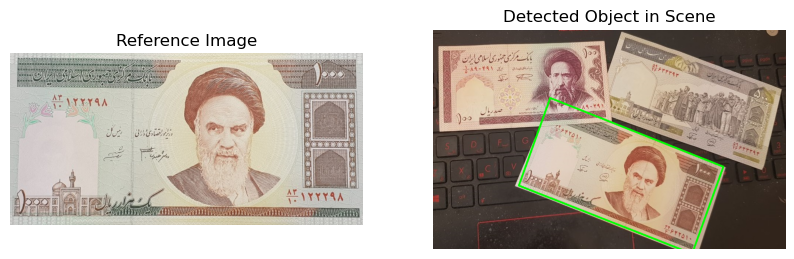

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(box[...,::-1])
axes[0].set_title("Reference Image")
axes[0].axis("off")

axes[1].imshow(box_in[...,::-1])
axes[1].set_title("Detected Object in Scene")
axes[1].axis("off")

plt.show()